# Stage 0 - Data Audit, Cleaning and EDA
TTTC2453 Final Group Project - D12 CIFAR-10

This notebook produces the required missing value audit, outlier analysis, class distribution, EDA plots, and preprocessing rationale.

In [1]:


import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/a213696/Group-5-ML-Project.git"
REPO_NAME = "Group-5-ML-Project"

CURRENT = Path.cwd()

if (CURRENT / "src").exists():
    PROJECT_ROOT = CURRENT

elif CURRENT.name == "notebooks" and (CURRENT.parent / "src").exists():
    PROJECT_ROOT = CURRENT.parent

else:
    BASE_DIR = Path("/content") if Path("/content").exists() else CURRENT
    PROJECT_ROOT = BASE_DIR / REPO_NAME

    if not PROJECT_ROOT.exists():
        print("Cloning repository from GitHub...")
        subprocess.run(["git", "clone", REPO_URL, str(PROJECT_ROOT)], check=True)
    else:
        print("Repository already exists. Pulling latest version...")
        subprocess.run(["git", "-C", str(PROJECT_ROOT), "pull"], check=False)

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIG_DIR = PROJECT_ROOT / "artifacts" / "figures"
TABLE_DIR = PROJECT_ROOT / "artifacts" / "tables"
MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
for d in [FIG_DIR, TABLE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Current working directory:", Path.cwd())
print("src exists:", (PROJECT_ROOT / "src").exists())
print("notebooks exists:", (PROJECT_ROOT / "notebooks").exists())

if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError("The src folder is missing. Upload src to GitHub or clone the full project repository, not only one notebook.")

import numpy as np, pandas as pd, hashlib
import matplotlib.pyplot as plt, seaborn as sns
from src.data import set_seeds, load_cifar10, split_train_val, scale_to_float, compute_channel_stats, normalize, flatten, check_duplicates, CLASSES
from src import viz
set_seeds(42)



Cloning repository from GitHub...
Project root: /content/Group-5-ML-Project
Current working directory: /content/Group-5-ML-Project
src exists: True
notebooks exists: False


## 1. Load data and check shape

In [2]:
x_train_full, y_train_full, x_test, y_test = load_cifar10()
print("x_train_full:", x_train_full.shape, x_train_full.dtype)
print("y_train_full:", y_train_full.shape, y_train_full.dtype)
print("x_test:", x_test.shape, x_test.dtype)
print("y_test:", y_test.shape, y_test.dtype)
print("Pixel range:", x_train_full.min(), "to", x_train_full.max())
print("Classes:", CLASSES)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
x_train_full: (50000, 32, 32, 3) uint8
y_train_full: (50000,) uint8
x_test: (10000, 32, 32, 3) uint8
y_test: (10000,) uint8
Pixel range: 0 to 255
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2. Missing value audit

In [3]:
missing_report = pd.DataFrame({
    "Split": ["Train", "Test"],
    "NaN count": [np.isnan(x_train_full.astype("float32")).sum(), np.isnan(x_test.astype("float32")).sum()],
    "Inf count": [np.isinf(x_train_full.astype("float32")).sum(), np.isinf(x_test.astype("float32")).sum()],
    "% missing": [0.0, 0.0],
    "Strategy": ["No imputation", "No imputation"],
    "Reason": ["No missing pixel values found", "No missing pixel values found"]
})
display(missing_report)

,Split,NaN count,Inf count,% missing,Strategy,Reason
0,Train,0,0,0.0,No imputation,No missing pixel values found
1,Test,0,0,0.0,No imputation,No missing pixel values found


## 3. Outlier analysis

In [4]:
pixel_report = pd.DataFrame({
    "Split": ["Train", "Test"],
    "Min pixel": [int(x_train_full.min()), int(x_test.min())],
    "Max pixel": [int(x_train_full.max()), int(x_test.max())],
    "Mean pixel": [round(float(x_train_full.mean()), 2), round(float(x_test.mean()), 2)],
    "Std pixel": [round(float(x_train_full.std()), 2), round(float(x_test.std()), 2)],
    "Decision": ["Keep all", "Keep all"]
})
display(pixel_report)
print("All pixels are valid uint8 values in the 0 to 255 range. No image removal is needed.")

,Split,Min pixel,Max pixel,Mean pixel,Std pixel,Decision
0,Train,0,255,120.71,64.15,Keep all
1,Test,0,255,121.53,64.06,Keep all


All pixels are valid uint8 values in the 0 to 255 range. No image removal is needed.


## 4. Duplicate check

In [5]:
u_train, u_test, cross = check_duplicates(x_train_full, x_test)
print("Unique train images:", u_train, "/", len(x_train_full))
print("Unique test images:", u_test, "/", len(x_test))
print("Cross-split duplicates:", cross)

Unique train images: 50000 / 50000
Unique test images: 10000 / 10000
Cross-split duplicates: 0


## 5. Class distribution

,Class,Train count,Test count
0,airplane,5000,1000
1,automobile,5000,1000
2,bird,5000,1000
3,cat,5000,1000
4,deer,5000,1000
5,dog,5000,1000
6,frog,5000,1000
7,horse,5000,1000
8,ship,5000,1000
9,truck,5000,1000


Imbalance ratio: 1.0


/content/Group-5-ML-Project/src/viz.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASSES, rotation=40, ha="right")
/content/Group-5-ML-Project/src/viz.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASSES, rotation=40, ha="right")


Saved → /content/Group-5-ML-Project/src/../artifacts/figures/eda_02_class_distribution.png


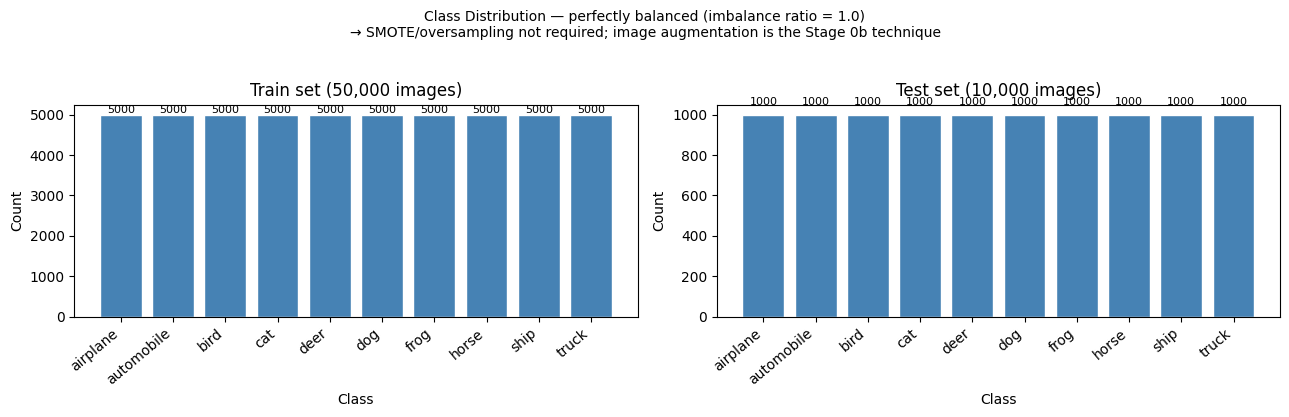

In [6]:
train_counts = np.bincount(y_train_full, minlength=10)
test_counts = np.bincount(y_test, minlength=10)
class_table = pd.DataFrame({"Class": CLASSES, "Train count": train_counts, "Test count": test_counts})
display(class_table)
print("Imbalance ratio:", train_counts.max() / train_counts.min())
viz.plot_class_distribution(y_train_full, y_test, save=True)

## 6. EDA visualisations

Saved → /content/Group-5-ML-Project/src/../artifacts/figures/eda_01_sample_grid.png


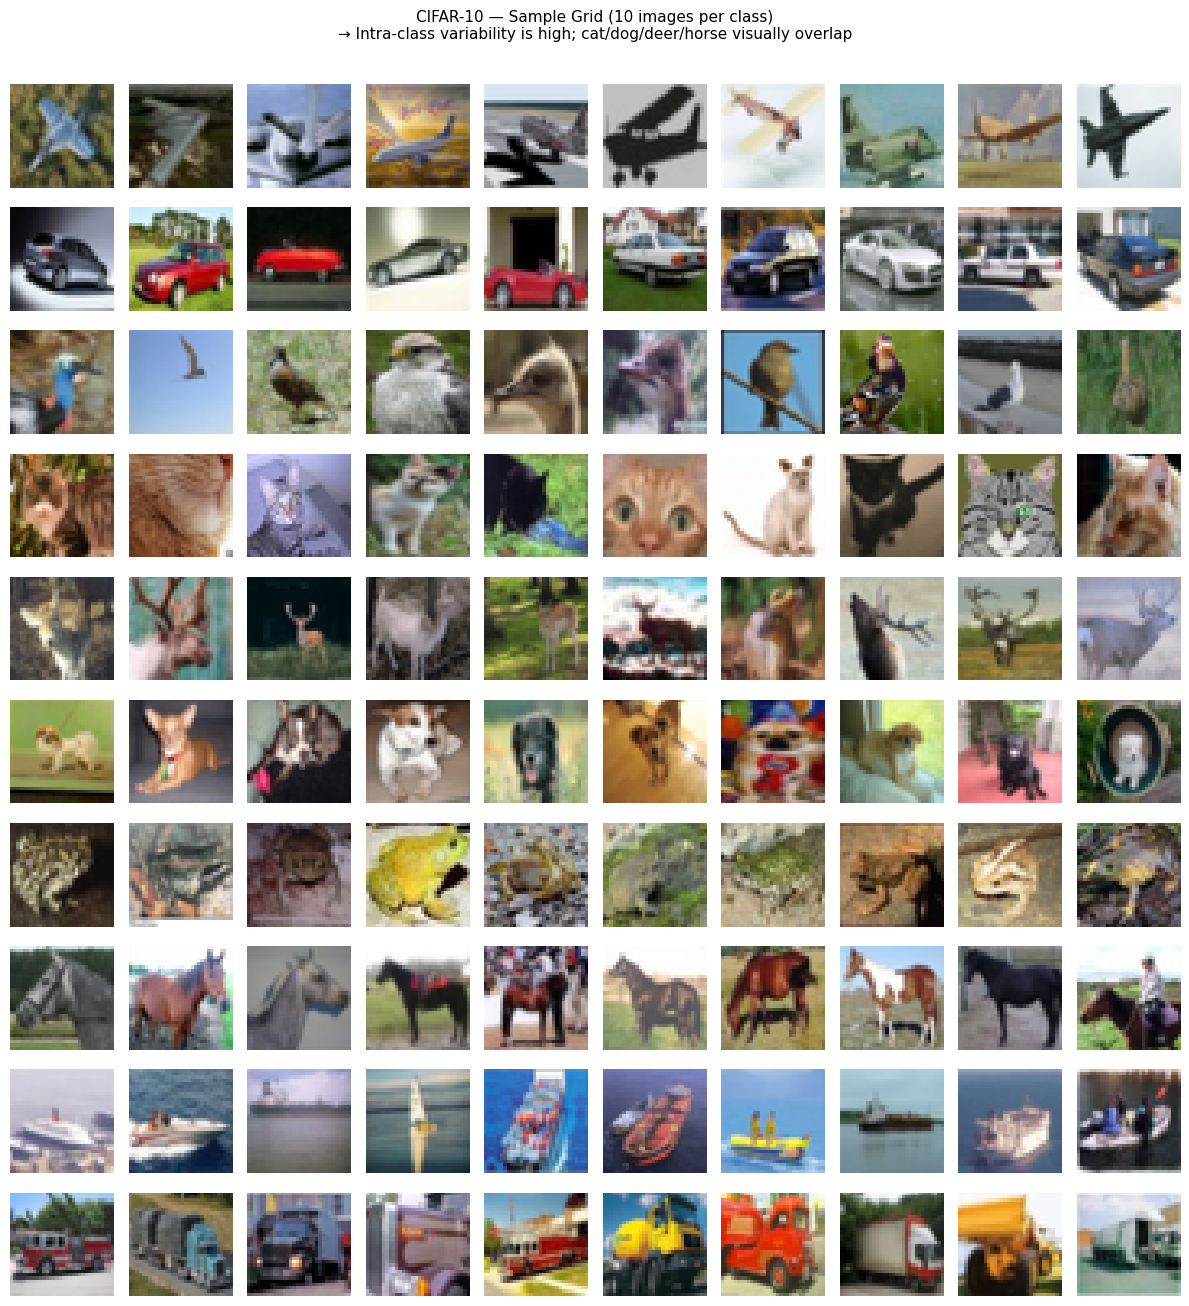

Saved → /content/Group-5-ML-Project/src/../artifacts/figures/eda_03_channel_histograms.png


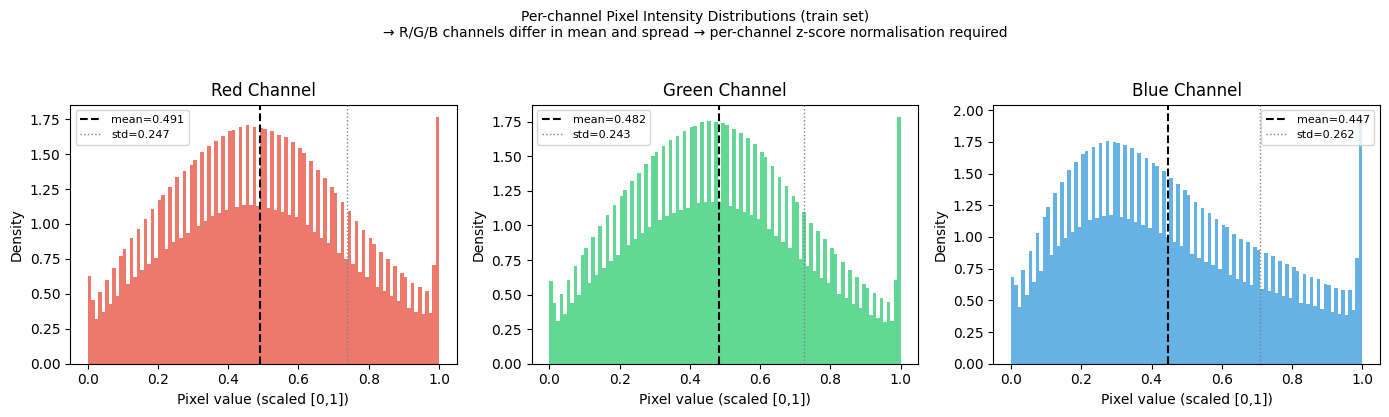

Saved → /content/Group-5-ML-Project/src/../artifacts/figures/eda_04_mean_images.png


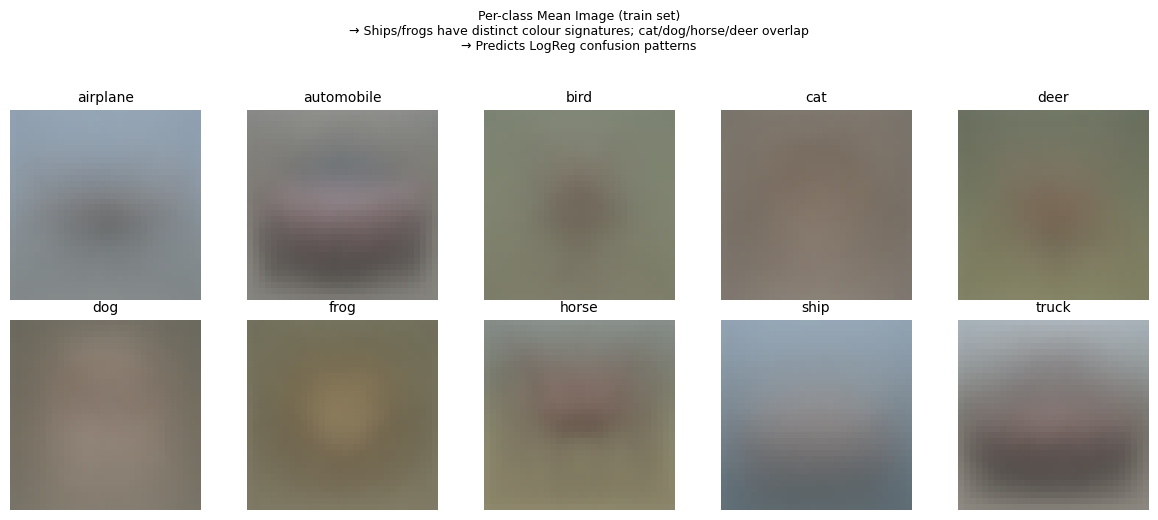

In [7]:
viz.plot_sample_grid(x_train_full, y_train_full, n_per_class=10, save=True)
x_train_f = scale_to_float(x_train_full)
viz.plot_channel_histograms(x_train_f, save=True)
viz.plot_mean_images(x_train_f, y_train_full, save=True)

## 7. Cleaning and preprocessing decisions

In [8]:
x_train, y_train, x_val, y_val = split_train_val(x_train_full, y_train_full, val_size=5000, seed=42)
x_train_f = scale_to_float(x_train); x_val_f = scale_to_float(x_val); x_test_f = scale_to_float(x_test)
mean, std = compute_channel_stats(x_train_f)
X_train = flatten(normalize(x_train_f, mean, std))
X_val = flatten(normalize(x_val_f, mean, std))
X_test = flatten(normalize(x_test_f, mean, std))
np.savez(TABLE_DIR / "splits.npz", X_train=X_train, X_val=X_val, X_test=X_test, y_train=y_train, y_val=y_val, y_test=y_test)
np.savez(TABLE_DIR / "norm_stats.npz", mean=mean, std=std)
summary = pd.DataFrame({
    "Aspect": ["Missing values", "Outliers", "Duplicates", "Class imbalance", "Normalisation", "Feature engineering"],
    "Decision": ["No imputation", "No removal", "0 cross-split duplicates", "No SMOTE/class weighting", "Per-channel train-only z-score", "Flatten to 3072 features for A/B"],
    "Reason": ["No NaN/Inf values", "All pixels within 0 to 255", "No leakage from duplicate images", "Every class has equal count", "RGB channels have different means/std", "Classical models need 2D feature matrix"]
})
display(summary)
print("Flat shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Train-only mean:", mean.round(4), "std:", std.round(4))

,Aspect,Decision,Reason
0,Missing values,No imputation,No NaN/Inf values
1,Outliers,No removal,All pixels within 0 to 255
2,Duplicates,0 cross-split duplicates,No leakage from duplicate images
3,Class imbalance,No SMOTE/class weighting,Every class has equal count
4,Normalisation,Per-channel train-only z-score,RGB channels have different means/std
5,Feature engineering,Flatten to 3072 features for A/B,Classical models need 2D feature matrix


Flat shapes: (45000, 3072) (5000, 3072) (10000, 3072)
Train-only mean: [0.491  0.4819 0.4465] std: [0.247  0.2434 0.2615]


## Written interpretation
The CIFAR-10 dataset is already clean because there are no missing values, no invalid pixel values, and no exact duplicate leakage between train and test. The class distribution is perfectly balanced with 5000 training images per class and 1000 test images per class, so class imbalance handling such as SMOTE is not needed. The EDA plots show that some classes are visually similar, especially cat, dog, deer, and horse, so a simple flattened-pixel model is expected to struggle. The RGB histogram also shows that the colour channels have different distributions, so per-channel normalisation using training statistics is used before modelling.